This notebook explores the dataset of Steam games to understand patterns in downloads, price, and genre.

Main goals:
- Understand distribution of downloads
- Analyze relationship between price and popularity
- Explore genre differences

In this section, we explore the dataset to understand the relationships between game features such as price and genre with estimated downloads.

In [10]:
import pandas as pd

#reading as csv
file1 = pd.read_csv("bestSelling_games.csv")
file2 = pd.read_csv("steam_games_2026.csv")

file1.head()
file2.head()

#the information of files
file1.info()
file2.info()

file1["game_name"] = file1["game_name"].str.lower().str.strip()
file2["Name"] = file2["Name"].str.lower().str.strip()

file1["game_name"].head()
file2["Name"].head()

#merging the same games
df = pd.merge(file1, file2, left_on="game_name", right_on="Name", how="inner")

#how big the data is
print(df.shape)

#seeing some of the merged file
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   game_name            2380 non-null   object 
 1   reviews_like_rate    2380 non-null   int64  
 2   all_reviews_number   2380 non-null   int64  
 3   release_date         2380 non-null   object 
 4   developer            2380 non-null   object 
 5   user_defined_tags    2380 non-null   object 
 6   supported_os         2380 non-null   object 
 7   supported_languages  2380 non-null   object 
 8   price                2380 non-null   float64
 9   other_features       2380 non-null   object 
 10  age_restriction      2380 non-null   int64  
 11  rating               2380 non-null   float64
 12  difficulty           2380 non-null   int64  
 13  length               2380 non-null   int64  
 14  estimated_downloads  2380 non-null   int64  
dtypes: float64(2), int64(6), object(7)
mem

,game_name,reviews_like_rate,all_reviews_number,release_date,developer,user_defined_tags,supported_os,supported_languages,price,other_features,...,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
0,counter-strike 2,86,8803754,"21 Aug, 2012",Valve,"FPS, Action, Tactical","win, linux","English, Czech, Danish, Dutch, Finnish, French...",0.00,"Cross-Platform Multiplayer, Steam Trading Card...",...,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0.00,0,83,4980365,Unknown,149410950,1013936
1,pubg: battlegrounds,59,2554482,"21 Dec, 2017",PUBG Corporation,"Survival, Shooter, Action, Tactical",win,"English, Korean, Simplified Chinese, French, G...",0.00,"Online PvP, Stats, Remote Play on Phone, Remot...",...,2017-12-21,Action,Survival;Shooter;Battle Royale;Multiplayer;FPS...,0.00,0,74,1757549,Unknown,52726470,314682
2,elden ring nightreign,77,53426,"30 May, 2025","FromSoftware, Inc.","Souls-like, Open World, Fantasy, RPG",win,"English, Japanese, French, Italian, German, Sp...",25.99,"Single-player, Online Co-op, Steam Achievement...",...,2025-05-29,Action,Souls-like;Online Co-Op;Multiplayer;Roguelike;...,39.99,0,80,122006,Unknown,3660180,163599
3,the last of us™ part i,79,45424,"28 Mar, 2023",Naughty Dog LLC,"Story Rich, Shooter, Survival, Horror",win,"English, Italian, Spanish - Spain, Czech, Dutc...",59.99,"Single-player, Steam Achievements, Steam Tradi...",...,2023-03-28,Action,Story Rich;Post-apocalyptic;Zombies;Horror;Act...,59.99,0,95,59411,Unknown,1782330,4144
4,red dead redemption 2,92,672140,"5 Dec, 2019",Rockstar Games,"Open World, Story Rich, Adventure, Realistic, ...",win,"English, French, Italian, German, Spanish - Sp...",59.99,"Single-player, Online PvP, Online Co-op, Steam...",...,2019-12-05,Action,Open World;Story Rich;Western;Multiplayer;Adve...,59.99,0,95,785860,Unknown,23575800,29885


The datasets were merged based on game names to combine sales and metadata information.

The dataset contains 424 rows and 27 columns, including variables such as price, estimated downloads, genre, and review scores.

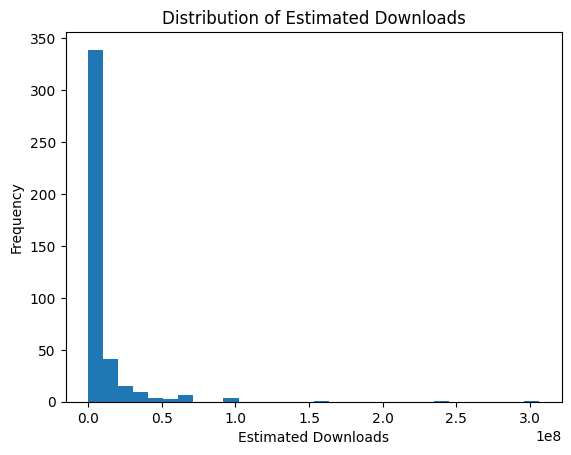

In [2]:
import matplotlib.pyplot as plt

#Showing the graph of downloads of games
plt.hist(df["estimated_downloads"], bins=30)
plt.title("Distribution of Estimated Downloads")
plt.xlabel("Estimated Downloads")
plt.ylabel("Frequency")
plt.show()

The histogram shows that the distribution of downloads is highly right-skewed.  
Most games have relatively low download counts, while a small number of games achieve very high popularity.

This suggests that the Steam market is dominated by a few highly successful titles.

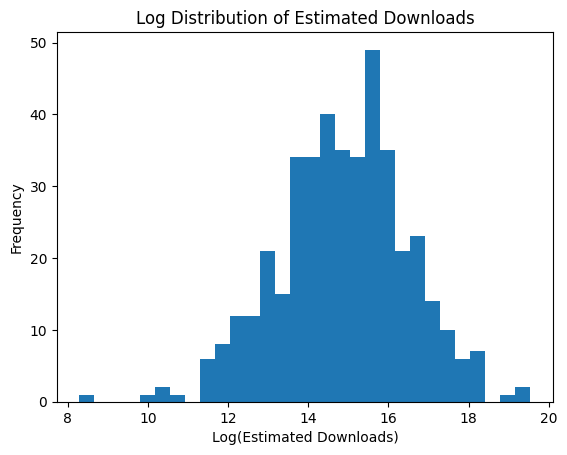

In [3]:
import numpy as np

#showing the graph in logarithmic format
plt.hist(np.log1p(df["estimated_downloads"]), bins=30)
plt.title("Log Distribution of Estimated Downloads")
plt.xlabel("Log(Estimated Downloads)")
plt.ylabel("Frequency")
plt.show()

Due to the highly skewed nature of download counts, a logarithmic transformation is applied to better understand the distribution.

The transformed distribution appears more balanced and closer to a normal distribution.  
This allows patterns in the data to be observed more clearly and reduces the impact of extremely popular games.

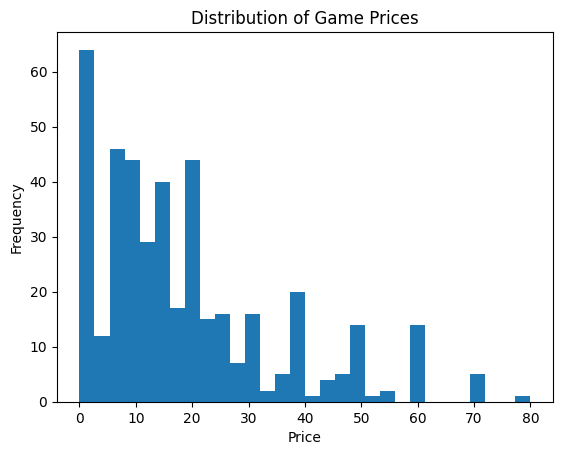

In [4]:
#showing graph of game prices in frequency
plt.hist(df["price"], bins=30)
plt.title("Distribution of Game Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

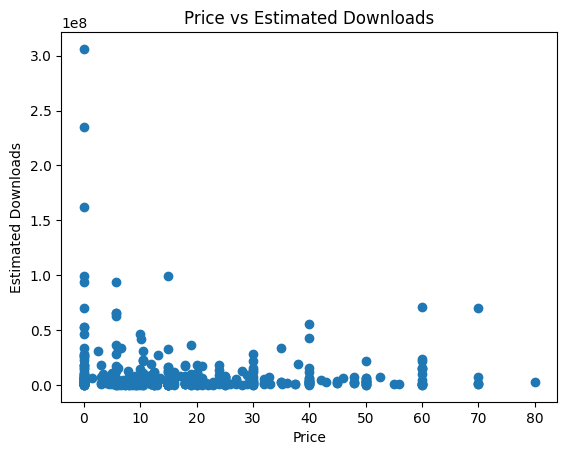

In [5]:
#graph of number of downloads for every game with price
plt.scatter(df["price"], df["estimated_downloads"])
plt.xlabel("Price")
plt.ylabel("Estimated Downloads")
plt.title("Price vs Estimated Downloads")
plt.show()

The presence of extreme values makes it difficult to visually interpret the relationship, which is why a logarithmic transformation is applied in the next step.

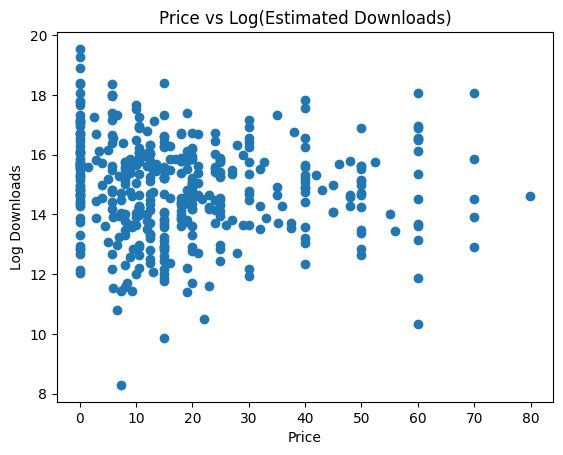

In [6]:
#showing the graph in logarithmic format
plt.scatter(df["price"], np.log1p(df["estimated_downloads"]))
plt.xlabel("Price")
plt.ylabel("Log Downloads")
plt.title("Price vs Log(Estimated Downloads)")
plt.show()

To better understand the relationship between price and downloads, a logarithmic transformation was applied to the download values.

The scatter plot shows a more balanced distribution compared to the original plot. However, there is still no strong visible relationship between price and downloads.

This suggests that while price may have some influence, it is not a dominant factor in determining game popularity.

In [7]:
df["price_category"] = pd.cut(df["price"],
                              bins=[-1, 0, 20, 50, 100],
                              labels=["Free", "Low", "Medium", "High"])

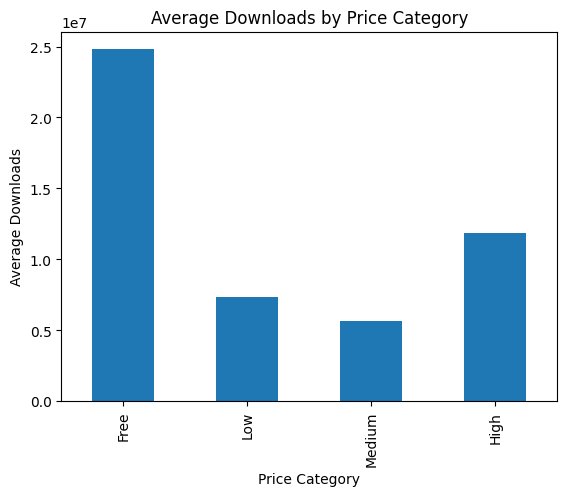

In [8]:
#graph of average downloads based on if the price category is free=0, low<=20, medium<=50 or high<=100
df.groupby("price_category", observed=False)["estimated_downloads"].mean().plot(kind="bar")

plt.title("Average Downloads by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Average Downloads")
plt.show()

The analysis shows that free games have significantly higher average downloads compared to paid games. Interestingly, high-priced games also maintain relatively strong download numbers, possibly due to brand recognition or quality perception. Low and medium-priced games do not outperform high-priced ones, suggesting that price alone does not determine popularity.

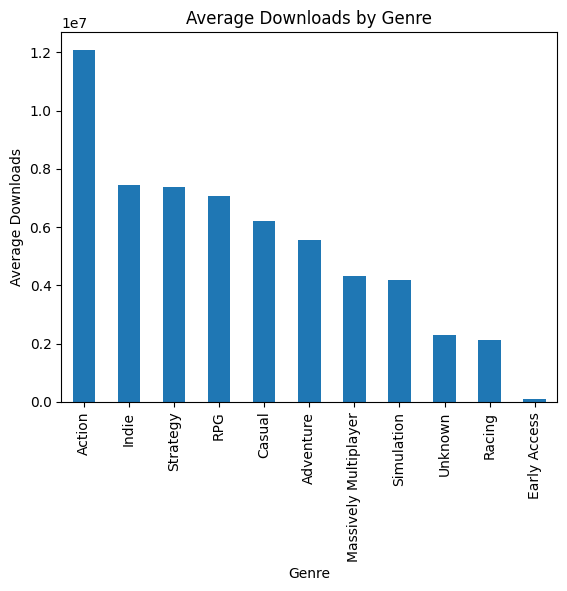

In [9]:
#shows the graph of average downloads based on genre
df.groupby("Primary_Genre")["estimated_downloads"].mean().sort_values(ascending=False).plot(kind="bar")

plt.title("Average Downloads by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Downloads")
plt.show()

The results show that genre has a noticeable impact on game popularity.

Action games have the highest average number of downloads by a large margin, indicating that they attract the widest player base.  
Indie, Strategy, and RPG games also perform well, forming a second tier of popular genres.

Casual and Adventure games show moderate performance, while genres such as Simulation and Massively Multiplayer have lower average downloads.

Overall, the exploratory data analysis suggests that game popularity (measured by downloads) is highly uneven, with a small number of games dominating the market.

Price does not show a strong direct relationship with downloads, although free games tend to perform better on average.

In contrast, genre appears to have a more noticeable impact on popularity, with certain genres such as Action and Indie attracting higher average downloads.

These findings motivate further statistical testing to determine whether these observed differences are statistically significant.